<a href="https://colab.research.google.com/github/DeeveshBeegun/machine_learning_handson/blob/main/backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

X, y = make_moons(
    n_samples=200,
    noise=0.20,
    random_state=42
)

X_tensor = torch.tensor(
    X,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y.reshape(-1, 1),
    dtype=torch.float32
)

In [2]:
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
  (3): Sigmoid()
)


In [3]:
predictions = model(X_tensor)

print(predictions[:5])

tensor([[0.5560],
        [0.4457],
        [0.4612],
        [0.4429],
        [0.4913]], grad_fn=<SliceBackward0>)


In [4]:
criterion = nn.BCELoss()

loss = criterion(
    predictions,
    y_tensor
)

print("Loss:", loss.item())

Loss: 0.792168378829956


In [5]:
for name, parameter in model.named_parameters():

    print(
        name,
        parameter.grad
    )

0.weight None
0.bias None
2.weight None
2.bias None


In [6]:
loss.backward()

In [7]:
for name, parameter in model.named_parameters():

    print("\n", name)

    print(parameter.grad)


 0.weight
tensor([[ 0.0457, -0.0223],
        [-0.0265,  0.0328],
        [ 0.0571, -0.0090],
        [ 0.0000,  0.0000],
        [-0.0171,  0.0470],
        [ 0.0326, -0.0199],
        [-0.0124,  0.0116],
        [ 0.0030, -0.0019]])

 0.bias
tensor([0.0075, 0.0435, 0.0401, 0.0000, 0.0530, 0.0077, 0.0153, 0.0011])

 2.weight
tensor([[-0.0504,  0.0327, -0.1349,  0.0000,  0.1558, -0.0533,  0.0042, -0.0446]])

 2.bias
tensor([-0.0195])


In [8]:
first_layer = model[0]

print(first_layer.weight)

Parameter containing:
tensor([[ 0.6070,  0.4683],
        [-0.5383,  0.6166],
        [ 0.6227, -0.6993],
        [ 0.0575,  0.0368],
        [-0.5721,  0.6105],
        [ 0.5582,  0.4421],
        [-0.2590,  0.2085],
        [ 0.3337,  0.2338]], requires_grad=True)


In [9]:
print(first_layer.weight.grad)

tensor([[ 0.0457, -0.0223],
        [-0.0265,  0.0328],
        [ 0.0571, -0.0090],
        [ 0.0000,  0.0000],
        [-0.0171,  0.0470],
        [ 0.0326, -0.0199],
        [-0.0124,  0.0116],
        [ 0.0030, -0.0019]])


In [10]:
weights_before = (
    model[0]
    .weight
    .detach()
    .clone()
)

print(weights_before)

tensor([[ 0.6070,  0.4683],
        [-0.5383,  0.6166],
        [ 0.6227, -0.6993],
        [ 0.0575,  0.0368],
        [-0.5721,  0.6105],
        [ 0.5582,  0.4421],
        [-0.2590,  0.2085],
        [ 0.3337,  0.2338]])


In [11]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [12]:
optimizer.step()

In [13]:
weights_after = (
    model[0]
    .weight
    .detach()
    .clone()
)

print(weights_after)

tensor([[ 0.6024,  0.4705],
        [-0.5356,  0.6133],
        [ 0.6170, -0.6984],
        [ 0.0575,  0.0368],
        [-0.5704,  0.6058],
        [ 0.5550,  0.4440],
        [-0.2578,  0.2073],
        [ 0.3334,  0.2340]])


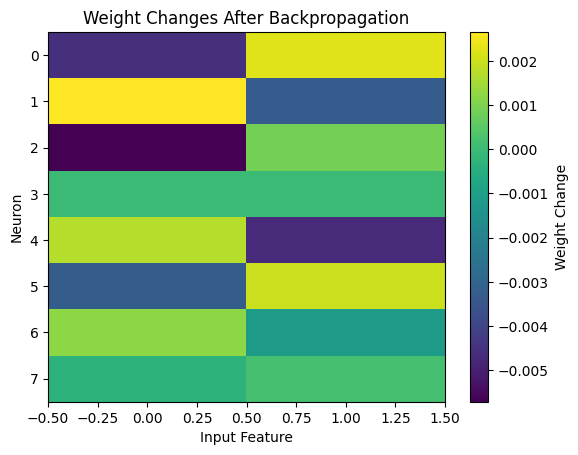

In [14]:
weight_change = (
    weights_after - weights_before
)

plt.imshow(
    weight_change.numpy(),
    aspect="auto"
)

plt.colorbar(
    label="Weight Change"
)

plt.xlabel("Input Feature")
plt.ylabel("Neuron")

plt.title(
    "Weight Changes After Backpropagation"
)

plt.show()

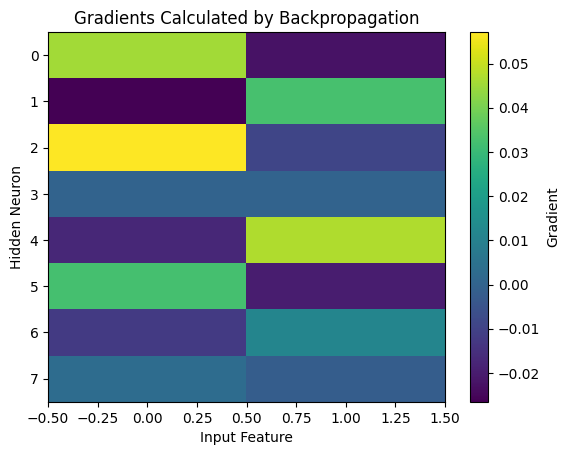

In [15]:
gradients = (
    model[0]
    .weight
    .grad
    .detach()
    .numpy()
)

plt.imshow(
    gradients,
    aspect="auto"
)

plt.colorbar(
    label="Gradient"
)

plt.xlabel("Input Feature")
plt.ylabel("Hidden Neuron")

plt.title(
    "Gradients Calculated by Backpropagation"
)

plt.show()

In [16]:
optimizer.zero_grad()

# Forward pass
predictions = model(X_tensor)

# Loss
loss = criterion(
    predictions,
    y_tensor
)

print(
    "Loss before update:",
    loss.item()
)

# Backpropagation
loss.backward()

# Update weights
optimizer.step()

Loss before update: 0.7852861881256104


In [17]:
with torch.no_grad():

    new_predictions = model(X_tensor)

    new_loss = criterion(
        new_predictions,
        y_tensor
    )

print(
    "Loss after update:",
    new_loss.item()
)

Loss after update: 0.7788281440734863


In [19]:
optimizer.zero_grad()